In [2]:
import mesa_reader as mr
import numpy as np
import os
from matplotlib import pyplot as plt, colors
%matplotlib widget

In [18]:
global_dir = '/homes/hanasoge/nipun_mesa/'
global_dir = '/home/nipunghanghas/nipun_mesa/control_saved_profile_rgb_grid/'
# global_dir = '/home/nipunghanghas/nipun_mesa/rgb_grid/'
# os.chdir(global_dir+'1M_pre_ms_to_wd')
os.chdir(global_dir)
os.chdir(global_dir)

In [19]:
pwd

'/home/nipunghanghas/nipun_mesa/control_saved_profile_rgb_grid'

In [27]:
# log_dir_local = f'RG_LOGS/{m_x}M{z_x}z{a}a{e_x}e'
# log_dir_local = f'RG_LOGS/1.75M0.001z2.2a0.001e'
log_dir_local = f'new_RG_LOGS/0.5M0.001z2.2a0.021e'
print(log_dir_local)
abs_path = global_dir+''
log_dir = abs_path+log_dir_local
# if not os.path.exists(log_dir):
    # os.makedirs(log_dir)
# write_rg_inlist(m_x,z_x,e_x,a,log_dir_local)
# print('Writing inlist completed')
# Add code to run the inlist
# subprocess.run(abs_path+'rn1',shell=True,check=True)

h = mr.MesaData(log_dir+'/history.data')
l = mr.MesaLogDir(log_dir)

tams_age = h.star_age[h.center_h1<1e-4][0]
select_model_number = h.model_number[(h.nu_max > 10)&(h.nu_max < 270)&(h.star_age>tams_age)&(h.delta_Pg>40)&(h.delta_Pg<500)]
req_model_numbers = np.intersect1d(l.model_numbers ,select_model_number)

if req_model_numbers.shape[0]>0:
    for number in req_model_numbers:
        number_profile = l.profile_with_model_number(number)
        p = l.profile_data(model_number=number)
        if p.model_number!=h.data_at_model_number('model_number',number):
            raise Exception('model_number in profile.data does not match with history.data')
        print(p.model_number,h.data_at_model_number('nu_max',number),h.data_at_model_number('delta_nu',number),h.data_at_model_number('delta_Pg',number),p.star_age)
        min_freq = h.data_at_model_number('nu_max',number)-h.data_at_model_number('delta_nu',number)
        max_freq = h.data_at_model_number('nu_max',number)+h.data_at_model_number('delta_nu',number)
        # print(h.data_at_model_number('nu_max',number),h.data_at_model_number('delta_nu',number))

new_RG_LOGS/0.5M0.001z2.2a0.021e
480 250.3236534641714 25.26103680079745 88.80979601732436 74321605917.952
490 228.66629869087913 23.595215987945622 86.91295854157157 74370395240.1291
500 209.70175440159713 22.104399685571337 85.20747005497643 74413276624.91821
510 192.94102323000953 20.758693392665915 83.51474368613421 74451186527.17207
520 178.11483042275339 19.544749370917735 82.09346963068508 74484915375.63051
530 164.87760920536797 18.439500577332872 80.79688884611964 74515006045.07527
540 153.03603432936796 17.432301966361628 79.4812262249683 74542041315.67053
550 142.3424018217772 16.50590947329615 78.3613755339968 74566405593.59326
560 132.72770814668803 15.659003086495257 77.31360060440925 74588495004.59904
570 124.00753433501927 14.877699182316872 76.24994251855065 74608540036.2891
580 116.09620738161868 14.157276457310683 75.31742516947475 74626807057.72543
590 108.86552898391578 13.48813899182223 74.44970317341637 74643515423.93402
600 102.25127879138901 12.866641500577035 

In [26]:
np.diff(h.star_age)

array([2.49586821e-04, 1.60729318e-03, 9.95193569e-03, 6.16197627e-02,
       3.81533329e-01, 2.36235381e+00, 1.46270721e+01, 9.05669753e+01,
       5.60766839e+02, 3.47212046e+03, 2.14984547e+04, 1.33112765e+05,
       8.24199157e+05, 5.10322394e+06, 1.50742478e+07, 3.93881215e+07,
       2.26369916e+08, 1.40162286e+09, 8.16222653e+09, 8.97195752e+09,
       7.16239001e+09, 7.38943053e+09, 8.52399030e+09, 7.41127685e+09,
       5.71479182e+09, 4.71054456e+09, 3.93352923e+09, 3.29512822e+09,
       1.55420513e+09, 5.18198674e+08, 3.90872569e+08, 3.21849606e+08,
       2.69238647e+08, 2.26953882e+08, 1.92794191e+08, 3.79561126e+08,
       1.31932830e+09, 6.72781628e+08, 3.75884984e+08, 2.60732734e+08,
       1.98140392e+08, 1.57951572e+08, 1.28176696e+08, 1.06092589e+08,
       8.89410414e+07, 7.54636355e+07, 6.47218554e+07, 5.59097677e+07,
       4.87893222e+07, 4.28813848e+07, 3.79099023e+07, 3.37288485e+07,
       3.00906694e+07, 2.70352706e+07, 2.43642779e+07, 2.20894110e+07,
      

In [59]:
h.file_name,h.bulk_names

('./LOGS_to_tams_2/history.data',
 ('model_number',
  'num_zones',
  'star_age',
  'log_dt',
  'star_mass',
  'log_xmstar',
  'log_abs_mdot',
  'mass_conv_core',
  'conv_mx1_top',
  'conv_mx1_bot',
  'conv_mx2_top',
  'conv_mx2_bot',
  'mx1_top',
  'mx1_bot',
  'mx2_top',
  'mx2_bot',
  'log_LH',
  'log_LHe',
  'log_LZ',
  'log_Lnuc',
  'pp',
  'cno',
  'tri_alpha',
  'epsnuc_M_1',
  'epsnuc_M_2',
  'epsnuc_M_3',
  'epsnuc_M_4',
  'epsnuc_M_5',
  'epsnuc_M_6',
  'epsnuc_M_7',
  'epsnuc_M_8',
  'he_core_mass',
  'co_core_mass',
  'one_core_mass',
  'fe_core_mass',
  'neutron_rich_core_mass',
  'log_Teff',
  'log_L',
  'log_R',
  'log_g',
  'v_div_csound_surf',
  'log_center_T',
  'log_center_Rho',
  'log_center_P',
  'center_mu',
  'center_ye',
  'center_abar',
  'center_h1',
  'center_he4',
  'center_c12',
  'center_o16',
  'surface_c12',
  'surface_o16',
  'total_mass_h1',
  'total_mass_he4',
  'delta_nu',
  'delta_Pg',
  'nu_max',
  'num_retries',
  'num_iters'))

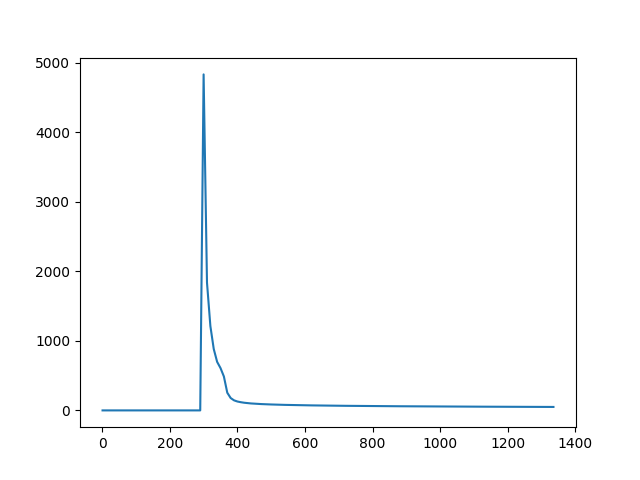

In [23]:
plt.figure()
# plt.plot(h.model_number,h.nu_max)
plt.plot(h.model_number,h.delta_Pg)
# plt.yscale('log')
plt.show()

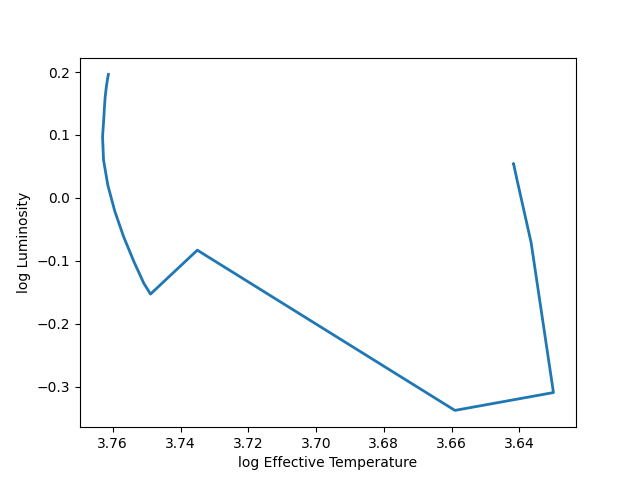

In [61]:
# load and plot data
# h = mr.MesaData('LOGS/history.data')
plt.figure()
plt.plot(h.log_Teff, h.log_L,lw=2)
# plt.plot(h.log_Teff,h.model_number)



# set axis labels
plt.xlabel('log Effective Temperature')
plt.ylabel('log Luminosity')
# invert the x-axis
plt.gca().invert_xaxis()
plt.show()

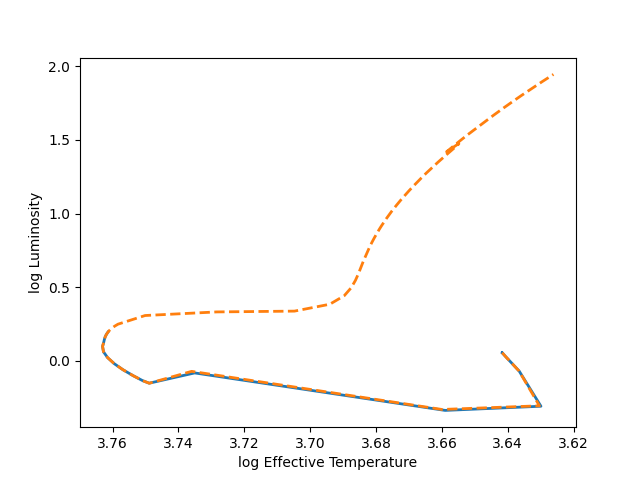

In [62]:
# load and plot data
# h = mr.MesaData('LOGS/history.data')
plt.figure()
plt.plot(h.log_Teff, h.log_L,lw=2)
plt.plot(h2.log_Teff, h2.log_L,lw=2,linestyle='--')
# plt.plot(h.log_Teff,h.model_number)



# set axis labels
plt.xlabel('log Effective Temperature')
plt.ylabel('log Luminosity')

# invert the x-axis
plt.gca().invert_xaxis()
plt.show()

In [63]:
# load the profile file into a MesaData instance
p = mr.MesaData(log_dir+'profile1.data')


# access the temperature column of data
temperatures = 10 ** p.logT

In [10]:
p.logT[0],temperatures[0]

(3.6417121125611387, 4382.400985384146)

In [11]:
h.star_age.shape,h.model_number.shape,temperatures.shape

((31,), (31,), (700,))

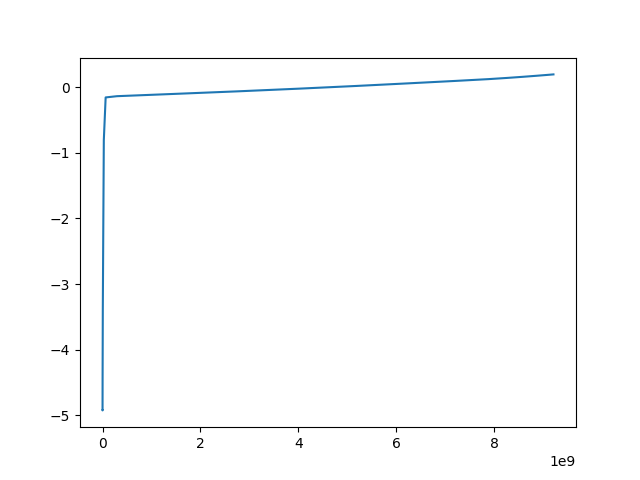

In [12]:
plt.figure()
# plt.plot(h.model_number,h.star_age)
# plt.plot(h.model_number,h.log_Teff)
# plt.plot(temperatures)
#plt.yscale('log')
# plt.plot(h.star_age,h.he_core_mass)
# plt.plot(h.star_age,h.center_h1)
# plt.plot(h.star_age,h.center_he4)
# plt.plot(h.star_age,h.log_Teff)
plt.plot(h.star_age,h.log_LH)
# plt.plot(h.star_age,h.log_LHe)
plt.show()

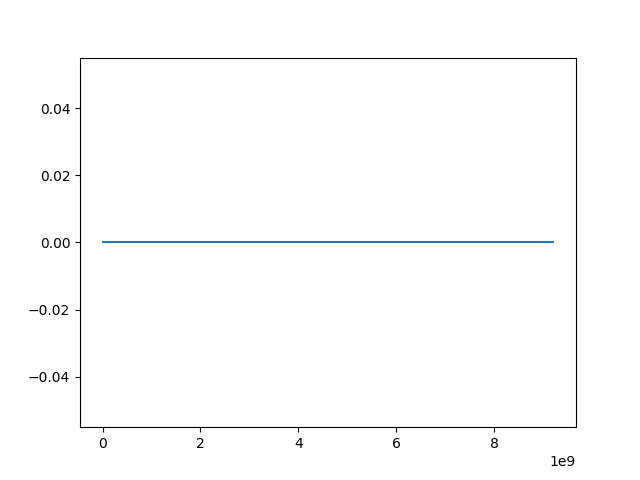

In [14]:
plt.figure()
# plt.plot(h.star_age,h.delta_nu)
# plt.plot(h.star_age,h.nu_max)
plt.plot(h.star_age,h.delta_Pg)
# plt.plot(h.delta_nu,h.nu_max)
# plt.plot(h.delta_nu,h.delta_Pg)
# plt.yscale('log')
plt.show()

In [15]:
import mesa_reader as mr

l = mr.MesaLogDir(log_dir)

# load the profile associated with model number 100
p_100 = l.profile_data(100)
# the same as the following
p_100 = l.profile_data(model_number=100)
l.profile_numbers,l.model_numbers

(array([1, 2, 3]), array([100, 200, 295]))

In [16]:
p_100.bulk_names

('zone',
 'mass',
 'logR',
 'logT',
 'logRho',
 'logP',
 'x_mass_fraction_H',
 'y_mass_fraction_He',
 'z_mass_fraction_metals',
 'csound',
 'pp',
 'cno',
 'tri_alpha',
 'brunt_N2',
 'lamb_Sl1')

In [17]:
# load the profile with PROFILE number 12
# p_12 = l.profile_data(profile_number=12)

# load the last profile saved (largest model number)
p_last = l.profile_data()


[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
[ 100  200  295  300  400  500  600  700  800  900 1000 1100 1126 1200
 1300 1400 1500 1536]


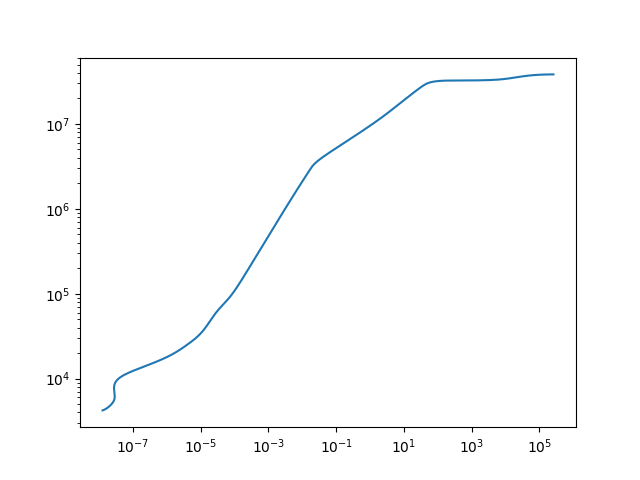

In [135]:
# load entire LOG directory information
l = mr.MesaLogDir(log_dir)
print(l.profile_numbers)
print(l.model_numbers)

# grab the last profile
p = l.profile_data()
# print(p.model_number,p.star_age)
# this works even if you only have logRho and logT!
plt.figure()
# plt.plot(p.Rho, p.T)
plt.loglog(p.Rho,p.T)
# plt.plot(p.R,p.T)
# plt.plot(p.R,p.Rho)
# plt.xlabel("Density")
# plt.ylabel("Temperature")
plt.show()

In [105]:
l.model_numbers,h.model_number

(array([ 100,  200,  295,  300,  400,  500,  600,  700,  800,  900, 1000,
        1100, 1126, 1200, 1300, 1400, 1500, 1536]),
 array([ 296,  300,  310,  320,  330,  340,  350,  360,  370,  380,  390,
         400,  410,  420,  430,  440,  450,  460,  470,  480,  490,  500,
         510,  520,  530,  540,  550,  560,  570,  580,  590,  600,  610,
         620,  630,  640,  650,  660,  670,  680,  690,  700,  710,  720,
         730,  740,  750,  760,  770,  780,  790,  800,  810,  820,  830,
         840,  850,  860,  870,  880,  890,  900,  910,  920,  930,  940,
         950,  960,  970,  980,  990, 1000, 1010, 1020, 1030, 1040, 1050,
        1060, 1070, 1080, 1090, 1100, 1110, 1120, 1126, 1130, 1140, 1150,
        1160, 1170, 1180, 1190, 1200, 1210, 1220, 1230, 1240, 1250, 1260,
        1270, 1280, 1290, 1300, 1310, 1320, 1330, 1340, 1350, 1360, 1370,
        1380, 1390, 1400, 1410, 1420, 1430, 1440, 1450, 1460, 1470, 1480,
        1490, 1500, 1510, 1520, 1530, 1536]))

In [63]:
p_100 = l.profile_data(model_number=100)

In [136]:
tams_age = h.star_age[h.center_h1<1e-4][0]
select_model_number = h.model_number[(h.nu_max > 100)&(h.nu_max < 270)&(h.star_age>tams_age)&(h.delta_Pg>40)&(h.delta_Pg<500)]
req_model_numbers = np.intersect1d(l.model_numbers ,select_model_number)

array([480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600,
       610, 620, 630])

(array([6, 7]), array([500, 600]))

In [139]:
req_model_numbers

array([500, 600])

In [143]:
p = l.profile_data(model_number=req_model_numbers[0])
p.model_number,p.star_age

(500, 12007152104.986586)

In [145]:
p.bulk_names

('zone',
 'mass',
 'logR',
 'logT',
 'logRho',
 'logP',
 'x_mass_fraction_H',
 'y_mass_fraction_He',
 'z_mass_fraction_metals',
 'pp',
 'cno',
 'tri_alpha')